In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [2]:
ENGINE_IDLE_RPM = 1600
ENGINE_ENGAGE_RPM = 2000
ENGINE_IDEAL_RPM = 3000
ENGINE_MAX_RPM = 3600

LOW_GEAR = 3.9
HIGH_GEAR = 0.9

# secondary rpm thresholds for gear shifting, calculated based on engine rpm and gear ratios
SLIP_SPEED = ENGINE_IDLE_RPM / LOW_GEAR # RPM
CRUISE_LOW = ENGINE_IDEAL_RPM / LOW_GEAR
CRUISE_HIGH = ENGINE_IDEAL_RPM / HIGH_GEAR
# secondary rpm where the CVT would first be able to lock at low gear
S_ENGAGE = ENGINE_ENGAGE_RPM / LOW_GEAR

def gear_ratio_from_secondary_rpm(x):
    """Return a gear ratio with a small slip-region on engage, and an
    engine-rpm clamp at `ENGINE_IDEAL_RPM` between the two gears.

    Behavior:
    - For very low secondary rpm the function returns `LOW_GEAR` (logical lock),
      but the CVT will actually be disengaged until engine reaches
      `ENGINE_ENGAGE_RPM` (handled in the plotting code).
    - Right after the CVT can first lock at low gear (`S_ENGAGE`) the ratio
      briefly transitions from a slightly higher "slip" ratio down to
      `LOW_GEAR` across `SLIP_SECONDARY_RANGE` to simulate slip-up/settle.
    - Between the low/high cruise thresholds it returns a ratio that keeps
      the engine at `ENGINE_IDEAL_RPM`.
    - Above the high cruise threshold it returns `HIGH_GEAR`.
    """
    # If using low gear produces engine RPM below ideal, stay in low gear
    if x * LOW_GEAR <= ENGINE_IDEAL_RPM:
        return LOW_GEAR

    # If using high gear would already be above ideal, stay in high gear
    if x * HIGH_GEAR >= ENGINE_IDEAL_RPM:
        return HIGH_GEAR

    # Otherwise, choose ratio so engine rpm stays at ENGINE_IDEAL_RPM
    return ENGINE_IDEAL_RPM / x

In [3]:
secondary_rpm = np.linspace(0,4000,1000)

# compute a nominal gear ratio for each secondary rpm
gear_ratio = [gear_ratio_from_secondary_rpm(i) for i in secondary_rpm]

# Effective secondary: before the CVT can engage (at S_ENGAGE) the secondary is held at 0
effective_secondary = np.where(secondary_rpm * LOW_GEAR < ENGINE_ENGAGE_RPM, 0, secondary_rpm)
effective_secondary = secondary_rpm

# Engine rpm: if effective_secondary==0 engine at idle; otherwise computed from ratio
# engine_rpm = []
# for s, r in zip(effective_secondary, gear_ratio):
#     if s == 0:
#         engine_rpm.append(ENGINE_IDLE_RPM)
#     else:
#         engine_rpm.append(s * r)
engine_rpm = effective_secondary * gear_ratio
engine_rpm = np.array(engine_rpm)

engine_rpm = np.where(engine_rpm < ENGINE_ENGAGE_RPM, ENGINE_ENGAGE_RPM, engine_rpm)
# engine_rpm = np.where((engine_rpm >= ENGINE_ENGAGE_RPM) & (engine_rpm < ENGINE_ENGAGE_RPM + 400), engine_rpm * 1.1, engine_rpm)

wheel_radius_inch = 11  # 22 inch diameter
inch_per_mile = 63360
minutes_per_hour = 60
geeb_reduction = 8.24
mph =  effective_secondary * (2 * 3.14159 * wheel_radius_inch) / inch_per_mile * minutes_per_hour / geeb_reduction

mph = np.insert(mph, 0, 0)
engine_rpm = np.insert(engine_rpm, 0, 0)



In [22]:
# PATH = "data/data_23.csv"
# PATH = "data/data_32.csv"
# df = pd.read_csv(PATH)

# # crop from time 112s to 132s
# df = df[(df["time_ms"] >= 25000) & (df["time_ms"] <= 88000)].copy()
# # df = df[(df["time_ms"] >= 112000) & (df["time_ms"] <= 124000)].copy()

PATH = "data/"
csv_files = [f for f in os.listdir(PATH) if f.endswith(".csv")]
df_list = []
for file in csv_files:
    df_list.append(pd.read_csv(os.path.join(PATH, file)))
df = pd.concat(df_list, ignore_index=True)

wheel_radius_inch = 11  # approximate effective radius of the wheel+sheave in inches
inch_per_mile = 63360
minutes_per_hour = 60
df["wheel_rpm_avg"] = df["rl_rpm"]
df["wheel_rpm_avg"] = df["wheel_rpm_avg"].rolling(window=3, center=True).mean()
df["speed_mph"] = df["wheel_rpm_avg"] * (2 * 3.14159 * wheel_radius_inch) / inch_per_mile * minutes_per_hour



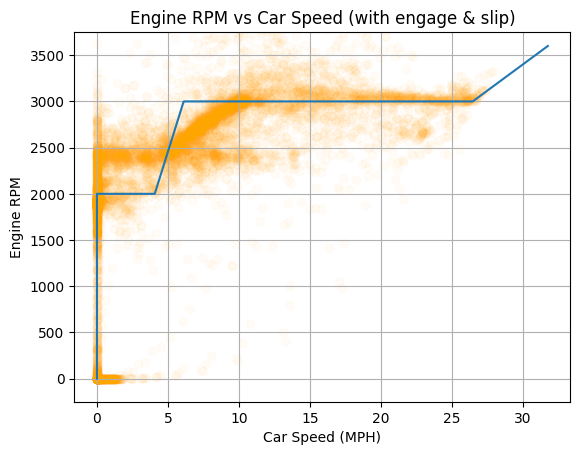

In [25]:
plt.plot(mph,engine_rpm)
plt.scatter(df["speed_mph"], df["engine_rpm"], color="orange", label="Actual Data", alpha=0.03)
plt.xlabel("Car Speed (MPH)")
plt.ylabel("Engine RPM")
plt.title("Engine RPM vs Car Speed (with engage & slip)")
plt.grid(True)
plt.ylim(-250,3750)
plt.show()